# Background evolution of the field

The goal of this program is to plot the evolution in redshift $z$ of the axion field $\chi_0$. The equation of motion is $$ \chi_0''+2\mathcal{H}\chi_0'+a(\tau)^2\frac{dV}{d\chi_0}=0\, , $$ where $'=\frac{d}{d\tau}$ and $\mathcal{H}$ is the Hubble ratio in conformal time.

As always I started by importing the necessary libraries: *NumPy* for the computations and mathematical symbols, *ScyPy* for the integrations and the differential equations and *Matplotlib* for the plots.

In [31]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

First of all, I defined the different constants that will be used in the computations. The values are the fiducial values of the $\Lambda CDM$ model.

In [32]:
Omegam=0.3153
Omegar=9.04e-5
OmegaL=0.6847
Omegak=0.0
H0=1.4e-33 # in eV
Mpl=1.22e28 # in eV
mpl=Mpl/np.sqrt(8*np.pi)

Then I wrote two functions for $H(a)$ and $\frac{da}{d\tau}$. The first to explicit the dependece of $H$ on $a(\tau)$ and the cosmological parameters. The second to find, through a numerical integration, the final value of $\tau$ that will be necessary to solve numerically the differential equation in the next line. The solution will be the function $a(\tau)$. Last, I compute the derivative of the potential $$V(\chi_0)=m_\chi ^2 M_{pl}^2 \left[1-\cos\left(\frac{\chi_0}{M_{pl}}\right)\right]^2\, .$$ These three functions ($H(a)$, $a(\tau)$ and $\frac{dV}{d\chi_0})$ will be necessary to find the solution of the EOM.

In [33]:
def V(x0, mx):
    return Mpl**2*mx**2*(1-np.cos(x0/Mpl))**2
def H(a):
    return H0*np.sqrt(Omegar*a**(-4)+Omegam*a**(-3)+Omegak*a**(-2)+OmegaL)
def dadt(t, a):
    return a**2*H(a)

tau_fin=sp.integrate.quad(lambda a:1./(a**2*H(a)), 1e-8, 1)[0]
a_ini=1e-8
a_tau=sp.integrate.solve_ivp(dadt, (0, tau_fin), [a_ini], dense_output=True)

def Vp(x0, mx):
    return 2*Mpl*mx**2*np.sin(x0/Mpl)*(1-np.cos(x0/Mpl))

Setting up the last few items for the plot and the calculation. I want to compute the evolution for different values of $m_\chi$, in this case they are $m_\chi\simeq10^{-32},\, 10^{-31},\, 10^{-30},\, 10^{-29},\, 10^{-28}\, \text{and}\, 10^{-27}\, \text{eV}$. To do so I create an array of these values of $m_\chi$ and then I create this small function to just plot them better later.

In [34]:
mx_values=np.logspace(-32, -27, 6)
def LaTex_mass(mx):
    exp=int(np.log10(mx))
    return rf'10^{{{exp}}}'

colors=['b', 'g', 'r', 'c', 'm', 'y']

I start now by defining the EOM by splitting it in a system of two first order differential equations.

In [35]:
def eom(tau, y, mx):
    x0, vx=y
    a=np.interp(tau, a_tau.t, a_tau.y[0])
    return [vx, -2*a*H(a)*vx-a**2*Vp(x0, mx)]

Solving the EOM for the different values of $m_\chi$ using as initial conditions $(\chi_0^{ini},\, v_\chi)=(m_{Pl},\, 0)$ by taking the $[0]$ element of *solution*. Later I divide it by the initial condition in order to obtain the ratio of the field with respect to the initial state. To show all of this I plot everything in a logarithmic scale as a function of redshift.

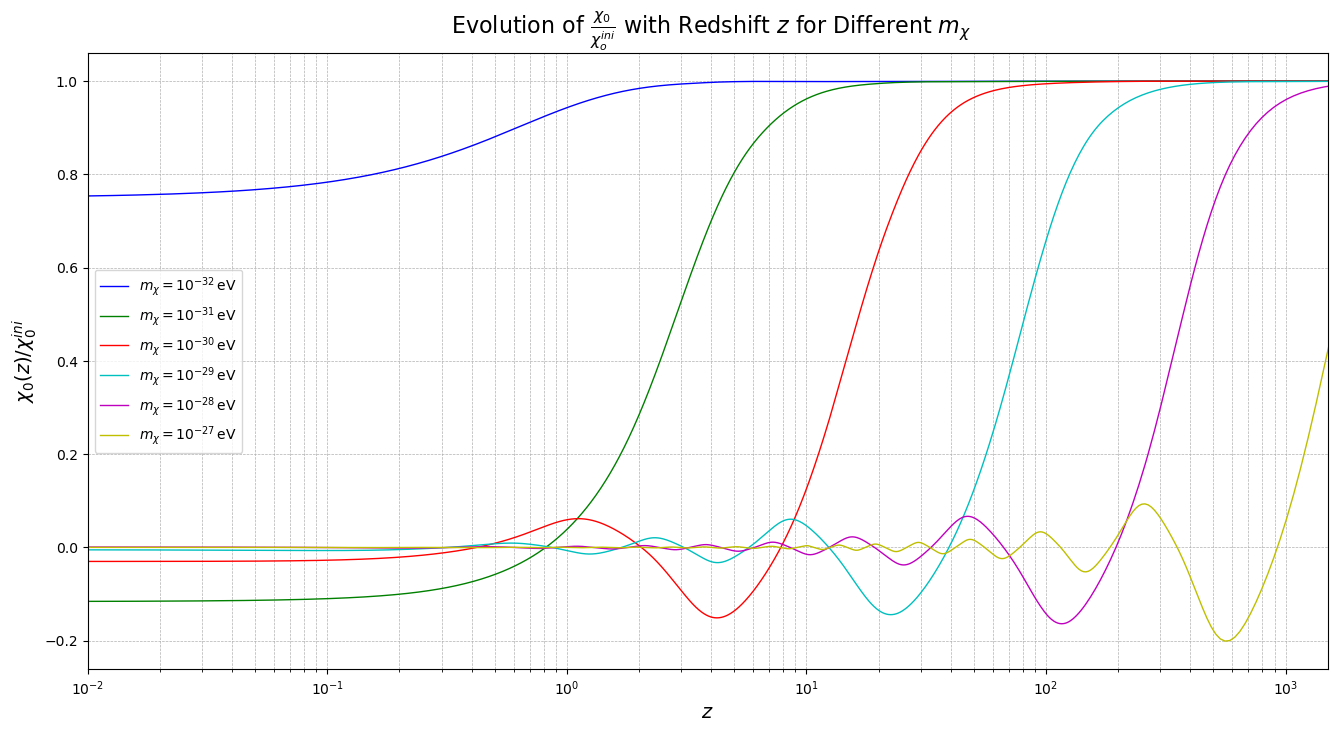

In [36]:
tau_grid=np.linspace(0, tau_fin, 1000)
plt.figure(figsize=(16, 8))

for mx, col in zip(mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (0,tau_fin), initial_conditions, args=(mx,), dense_output=True)
    
    chi_tau=solution.sol(tau_grid)[0]
    s=chi_tau/initial_conditions[0]
    z_values=1./a_tau.sol(tau_grid)[0]-1.
    plt.plot(z_values, s, color=col, label=rf'$m_\chi = {LaTex_mass(mx)}\, \mathrm{{eV}}$', linewidth=1)


plt.xscale('log')
plt.xticks([1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3])
plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 1500)
plt.ylabel(r'$\chi_0 (z)/ \chi_0^{ini}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r' Evolution of $\frac{\chi_0}{\chi_o^{ini}}$ with Redshift $z$ for Different $m_\chi$', fontsize=16)
plt.legend()
plt.show()

Moreover, it is possible to compute the value of $\omega_{\chi_0}$, i.e. the ratio of the equation of state of $\chi_0$. To do so I can simply take the second result given by the integration of the equation of motion, $\chi_0'(\tau)=v_{\chi_0}$, and using the formula $$ \omega_{\chi_0}=\frac{\chi_0'-2a^2V(\chi_0)}{\chi_0'+2a^2V(\chi_0)}\, ,$$ we get the evolution of omega in redshift.

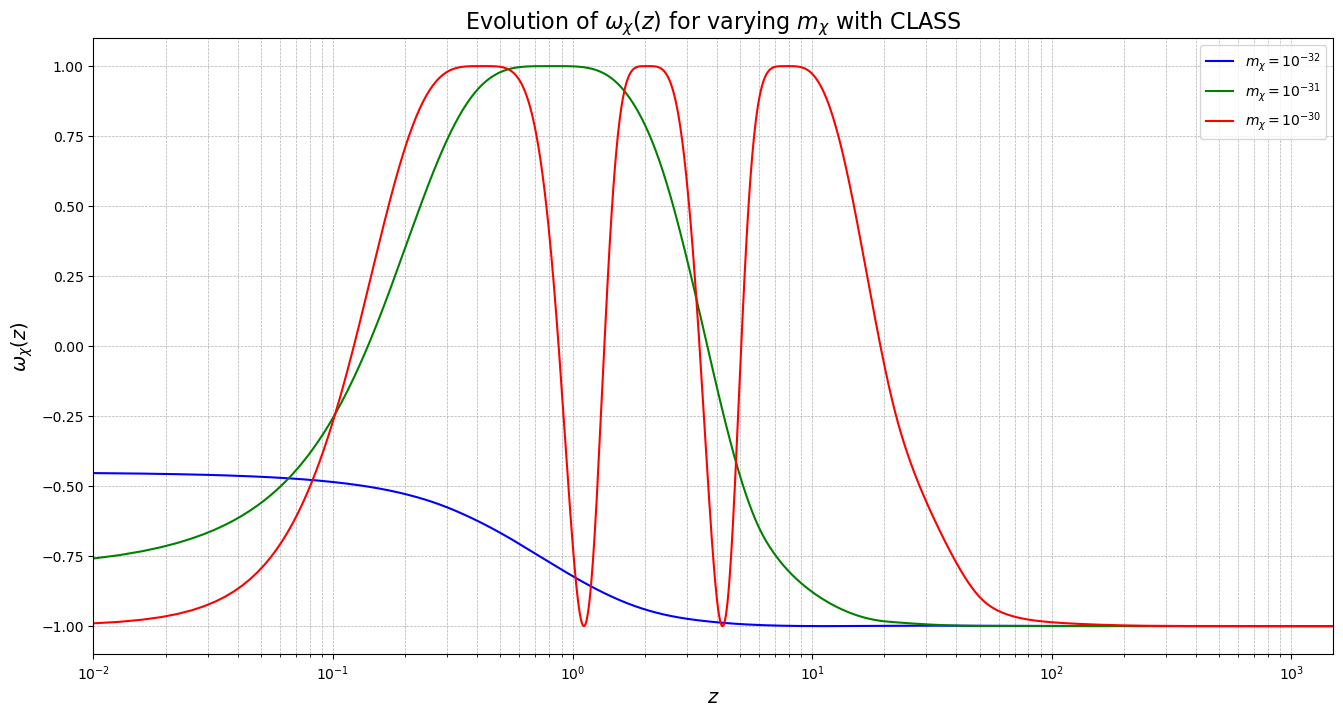

In [42]:
plt.figure(figsize=(16, 8))
plt.xscale('log')

mx_values=np.logspace(-32, -30, 3)
for mx, col in zip(mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (0, tau_fin), initial_conditions, args=(mx,), dense_output=True)

    vx_solution=solution.sol(tau_grid)[1]
    
    omega=(vx_solution**2-2*a_tau.sol(tau_grid)[0]**2*V(solution.sol(tau_grid)[0], mx))/(vx_solution**2+2*a_tau.sol(tau_grid)[0]**2*V(solution.sol(tau_grid)[0], mx))
    z_values=1./a_tau.sol(tau_grid)[0]-1.
    plt.plot(z_values, omega, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$') 


plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 1500)
plt.ylabel(r'$\omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\omega_\chi(z)$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show() 